In [ ]:
import math
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline
import torch
import torch.nn.functional as F

In [ ]:
words = open('names.txt', 'r').read().splitlines()
print(f"Total words: {len(words)}")

Total words: 32033


In [ ]:
unique_chars = sorted(list(set(''.join(words))))
if '.' in unique_chars:
    unique_chars.remove('.')
chars = ['.'] + unique_chars
stoi = {ch: i for i, ch in enumerate(chars)}
itos = {i: ch for ch, i in stoi.items()}
vocab_size = len(chars)
print(f"Vocabulary size: {vocab_size}")

one_hot_vector = F.one_hot(torch.tensor(list(stoi.values())), num_classes=vocab_size).float()

Vocabulary size: 27


---
## Part 1 — Vanilla RNN

### Parameter Initialisation

**Critical fix — non-leaf tensor bug:**
```python
# WRONG: multiplying after requires_grad=True creates a non-leaf tensor
# p.grad will always be None, and p.data access raises RuntimeError
x = torch.randn(vocab_size, vocab_size, requires_grad=True) * 0.01

# CORRECT: multiply first, then tag as leaf with requires_grad_(True)
x = (torch.randn(vocab_size, vocab_size) * 0.01).requires_grad_(True)
```

In [ ]:
torch.manual_seed(42)

# FIX 6: multiply BEFORE requires_grad_ so result is a proper leaf tensor
x  = (torch.randn(vocab_size, vocab_size) * 0.01).requires_grad_(True)
y  = (torch.randn(vocab_size)             * 0.01).requires_grad_(True)
hy = (torch.randn(vocab_size, vocab_size) * 0.01).requires_grad_(True)
hh = (torch.randn(vocab_size, vocab_size) * 0.01).requires_grad_(True)
yh = (torch.randn(vocab_size)             * 0.01).requires_grad_(True)

parameters = [x, y, hy, hh, yh]

# FIX 2: learning rate 0.1 -> 0.001
lr = 0.001

# Sanity check: all must be leaf tensors for .grad to be populated
for name, p in zip(['x', 'y', 'hy', 'hh', 'yh'], parameters):
    print(f"{name}: is_leaf={p.is_leaf}, requires_grad={p.requires_grad}")

x: is_leaf=True, requires_grad=True
y: is_leaf=True, requires_grad=True
hy: is_leaf=True, requires_grad=True
hh: is_leaf=True, requires_grad=True
yh: is_leaf=True, requires_grad=True


### Vanilla RNN — Training Loop

In [6]:
loss_history = []
for epoch in range(200):
    epoch_loss = 0.0
    for w in words:
        for p in parameters:
            if p.grad is not None:
                p.grad.zero_()
        w_padded = '.' + w + '.'
        h1 = torch.zeros(vocab_size)
        step_losses = []
        for ch1_str, ch2_str in zip(w_padded, w_padded[1:]):
            ch1_idx = stoi[ch1_str]
            ch2_idx = stoi[ch2_str]
            h_input     = x @ one_hot_vector[ch1_idx] + hy @ h1 + y
            h_activated = h_input.tanh()
            h1 = h_activated.detach()
            out = hh @ h_activated + yh
            step_losses.append(
                F.cross_entropy(out.unsqueeze(0), torch.tensor(ch2_idx).unsqueeze(0))
            )
        if not step_losses:
            continue
        word_loss = torch.stack(step_losses).sum()
        word_loss.backward()
        torch.nn.utils.clip_grad_norm_(parameters, max_norm=1.0)
        for p in parameters:
            if p.grad is not None:
                p.data += -lr * p.grad
        epoch_loss += word_loss.item()
    loss_history.append(epoch_loss)
    if epoch % 10 == 0:
        print(f"Epoch {epoch:3d} | Loss: {epoch_loss:.4f}")

Epoch   0 | Loss: 642492.6315
Epoch  10 | Loss: 538101.0511
Epoch  20 | Loss: 526127.4061
Epoch  30 | Loss: 519266.6155
Epoch  40 | Loss: 515007.8205
Epoch  50 | Loss: 511622.0046
Epoch  60 | Loss: 508664.3176
Epoch  70 | Loss: 506288.3222
Epoch  80 | Loss: 504393.2338
Epoch  90 | Loss: 502805.7393
Epoch 100 | Loss: 501466.8744
Epoch 110 | Loss: 500313.9709
Epoch 120 | Loss: 499306.9170
Epoch 130 | Loss: 498431.5250
Epoch 140 | Loss: 497688.1298
Epoch 150 | Loss: 497072.8236
Epoch 160 | Loss: 496569.1644
Epoch 170 | Loss: 496153.8345
Epoch 180 | Loss: 495803.7028
Epoch 190 | Loss: 495500.1444


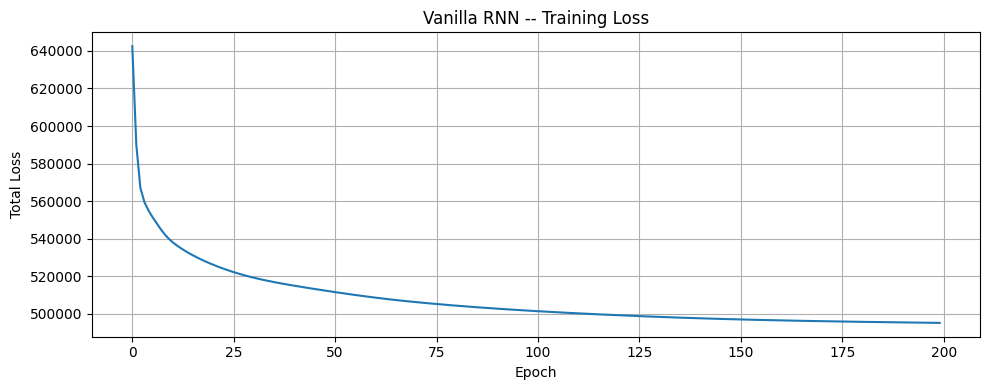

In [7]:
plt.figure(figsize=(10, 4))
plt.plot(loss_history)
plt.title('Vanilla RNN -- Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Total Loss')
plt.grid(True)
plt.tight_layout()
plt.show()

### Vanilla RNN — Name Generation

In [8]:
torch.manual_seed(0)
print("Generated names (Vanilla RNN):")
for _ in range(10):
    h_sample    = torch.zeros(vocab_size)
    word_sample = ['.']

    for _ in range(20):
        ix          = stoi[word_sample[-1]]
        h_input     = x @ one_hot_vector[ix] + hy @ h_sample + y
        h_activated = h_input.tanh()
        h_sample    = h_activated.detach()
        out         = hh @ h_activated + yh
        probs       = F.softmax(out, dim=0)
        next_ix     = torch.multinomial(probs, num_samples=1).item()
        next_char   = itos[next_ix]
        word_sample.append(next_char)
        if next_char == '.':
            break

    print(''.join(word_sample[1:-1]))

Generated names (Vanilla RNN):
kedleen
nahmar
adery
besuxhae
krion
kefslyn
reziall
kayoci
hushan
exa


---
## Part 2 — LSTM

Same leaf-tensor fix applied throughout. Biases are created with `torch.ones/zeros`
then `.requires_grad_(True)` — these are already the final tensors so no multiplication needed.

In [ ]:
words = open('names.txt', 'r').read().splitlines()

unique_chars = sorted(list(set(''.join(words))))
if '.' in unique_chars:
    unique_chars.remove('.')
chars = ['.'] + unique_chars
stoi = {ch: i for i, ch in enumerate(chars)}
itos = {i: ch for ch, i in stoi.items()}
vocab_size = len(chars)

one_hot_vector = F.one_hot(torch.tensor(list(stoi.values())), num_classes=vocab_size).float()

In [ ]:
torch.manual_seed(42)

# FIX 6: multiply first, then requires_grad_(True) -- proper leaf tensors
x_f = (torch.randn(vocab_size, vocab_size) * 0.01).requires_grad_(True)
x_i = (torch.randn(vocab_size, vocab_size) * 0.01).requires_grad_(True)
x_o = (torch.randn(vocab_size, vocab_size) * 0.01).requires_grad_(True)
x_c = (torch.randn(vocab_size, vocab_size) * 0.01).requires_grad_(True)

u_f = (torch.randn(vocab_size, vocab_size) * 0.01).requires_grad_(True)
u_i = (torch.randn(vocab_size, vocab_size) * 0.01).requires_grad_(True)
u_o = (torch.randn(vocab_size, vocab_size) * 0.01).requires_grad_(True)
u_c = (torch.randn(vocab_size, vocab_size) * 0.01).requires_grad_(True)

W_out = (torch.randn(vocab_size, vocab_size) * 0.01).requires_grad_(True)

# Biases: forget gate = 1 (remember by default), all others = 0
y_f   = torch.ones (vocab_size).requires_grad_(True)   # forget gate bias = 1
y_i   = torch.zeros(vocab_size).requires_grad_(True)
y_o   = torch.zeros(vocab_size).requires_grad_(True)
y_c   = torch.zeros(vocab_size).requires_grad_(True)
b_out = torch.zeros(vocab_size).requires_grad_(True)

parameters = [x_f, x_i, x_o, x_c, u_f, u_i, u_o, u_c, W_out,
               y_f, y_i, y_o, y_c, b_out]

lr = 0.001
print(f"Total parameters: {sum(p.numel() for p in parameters)}")

# Verify all are leaf tensors
assert all(p.is_leaf for p in parameters), "Some parameters are not leaf tensors!"
print("All parameters are leaf tensors checkmark")

Total parameters: 6696
All parameters are leaf tensors checkmark


### LSTM — Training Loop

In [ ]:
lstm_loss_history = []

for epoch in range(200):
    epoch_loss = 0.0

    for w in words:   # FIX 6: full dataset, not words[:1000]
        for p in parameters:
            if p.grad is not None:
                p.grad.zero_()

        w_padded = '.' + w + '.'
        h1 = torch.zeros(vocab_size)
        c1 = torch.zeros(vocab_size)
        step_losses = []

        for ch1_str, ch2_str in zip(w_padded, w_padded[1:]):
            ch1_idx = stoi[ch1_str]
            ch2_idx = stoi[ch2_str]
            inp = one_hot_vector[ch1_idx]

            f_t  = torch.sigmoid(x_f @ inp + u_f @ h1 + y_f)
            i_t  = torch.sigmoid(x_i @ inp + u_i @ h1 + y_i)
            o_t  = torch.sigmoid(x_o @ inp + u_o @ h1 + y_o)
            c__t = torch.tanh   (x_c @ inp + u_c @ h1 + y_c)
            c_t  = f_t * c1 + i_t * c__t
            h_t  = o_t * torch.tanh(c_t)

            out  = W_out @ h_t + b_out
            step_losses.append(
                F.cross_entropy(out.unsqueeze(0), torch.tensor(ch2_idx).unsqueeze(0))
            )

            # FIX 5: detach both hidden and cell state
            h1 = h_t.detach()
            c1 = c_t.detach()

        if not step_losses:
            continue

        word_loss = torch.stack(step_losses).sum()
        word_loss.backward()

        torch.nn.utils.clip_grad_norm_(parameters, max_norm=1.0)

        # FIX 7: None-guard
        for p in parameters:
            if p.grad is not None:
                p.data += -lr * p.grad
        epoch_loss += word_loss.item()
    lstm_loss_history.append(epoch_loss)
    if epoch % 10 == 0:
        print(f"Epoch {epoch:3d} | Loss: {epoch_loss:.4f}")

Epoch   0 | Loss: 660300.2926
Epoch  10 | Loss: 555815.1579
Epoch  20 | Loss: 540998.8997
Epoch  30 | Loss: 530663.6635
Epoch  40 | Loss: 524012.3025
Epoch  50 | Loss: 519555.0216
Epoch  60 | Loss: 516373.2080
Epoch  70 | Loss: 514029.9137
Epoch  80 | Loss: 512282.6891
Epoch  90 | Loss: 510858.2235
Epoch 100 | Loss: 509540.8028
Epoch 110 | Loss: 508200.3965
Epoch 120 | Loss: 506850.1987
Epoch 130 | Loss: 505515.7941
Epoch 140 | Loss: 504214.1811
Epoch 150 | Loss: 502979.1682
Epoch 160 | Loss: 501833.3020
Epoch 170 | Loss: 500783.9244
Epoch 180 | Loss: 499834.9725
Epoch 190 | Loss: 498982.2113


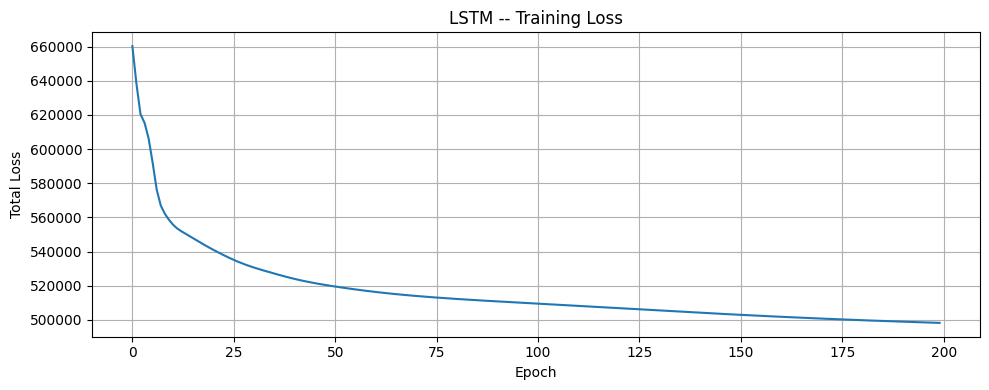

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(lstm_loss_history)
plt.title('LSTM -- Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Total Loss')
plt.grid(True)
plt.tight_layout()
plt.show()

### LSTM — Name Generation

In [ ]:
torch.manual_seed(0)
print("Generated names (LSTM):")
for _ in range(10):
    h_sample = torch.zeros(vocab_size)
    c_sample = torch.zeros(vocab_size)
    word_sample = ['.']

    for _ in range(20):
        ix  = stoi[word_sample[-1]]
        inp = one_hot_vector[ix]

        f_t  = torch.sigmoid(x_f @ inp + u_f @ h_sample + y_f)
        i_t  = torch.sigmoid(x_i @ inp + u_i @ h_sample + y_i)
        o_t  = torch.sigmoid(x_o @ inp + u_o @ h_sample + y_o)
        c__t = torch.tanh   (x_c @ inp + u_c @ h_sample + y_c)
        c_t  = f_t * c_sample + i_t * c__t
        h_t  = o_t * torch.tanh(c_t)

        out   = W_out @ h_t + b_out
        probs = F.softmax(out, dim=0)
        next_ix   = torch.multinomial(probs, num_samples=1).item()
        next_char = itos[next_ix]
        word_sample.append(next_char)

        h_sample = h_t.detach()
        c_sample = c_t.detach()

        if next_char == '.':
            break

    print(''.join(word_sample[1:-1]))

Generated names (LSTM):
kedlein
nonkey
aderloues
lyley
rion
kefstius
mirall
kayocik
shanileet
macyleen
